In [ ]:
!pip install -q pymorphy3 wordcloud plotly hdbscan nltk scikit-learn seaborn tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import hdbscan
from nltk.util import ngrams
import nltk
from transformers import pipeline
import pymorphy3

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from tqdm import tqdm
tqdm.pandas()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 58.1 MB/s eta 0:00:00


In [ ]:
path = '/content/drive/MyDrive/мага/Диссер/data_nonan.csv'
data = pd.read_csv(path, parse_dates=['date'])

data['year'] = data['year'].astype('int16')
for col in ['likes', 'comments_count', 'reposts', 'views']:
  data[col] = pd.to_numeric(data[col])

data['month'] = data['date'].dt.month.astype('int8')
season_map = {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
data['season'] = data['month'].map(season_map).astype('int8')
season_names = {1:'Зима', 2:'Весна', 3:'Лето', 4:'Осень'}
data['season_name'] = data['season'].map(season_names)

print('Посмотрим на данные')
print(data.info())
print('\n Описательные статистики:')
print(data[['likes', 'comments_count', 'reposts', 'views', 'year']].describe())

fig_table = data.groupby(['year', 'month']).size().reset_index(name='count')
fig = px.line(fig_table, x='month', y='count', color='year',
              title='Динамика публикаций по месяцам и годам',
              labels={'month':'Месяц', 'count':'Количество постов'})
fig.show()

pivot_ = data.pivot_table(index='year', columns='month', values='post_id', aggfunc='count', fill_value=0)

season_counts = data.groupby(['year', 'season_name']).size().reset_index(name='count')
fig2 = px.bar(season_counts, x='year', y='count', color='season_name', barmode='group',
              title='Сезонность публикаций по годам',
              labels={'count':'Постов', 'year':'Год'})
fig2.show()

Посмотрим на данные
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779621 entries, 0 to 779620
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   post_id          779621 non-null  int64         
 1   date             779621 non-null  datetime64[ns]
 2   text             779621 non-null  object        
 3   likes            779621 non-null  int64         
 4   comments_count   779621 non-null  int64         
 5   reposts          779621 non-null  int64         
 6   views            779621 non-null  int64         
 7   year             779621 non-null  int16         
 8   source_nickname  779621 non-null  object        
 9   month            779621 non-null  int8          
 10  season           779621 non-null  int8          
 11  season_name      779621 non-null  object        
dtypes: datetime64[ns](1), int16(1), int64(5), int8(2), object(3)
memory usage: 56.5+ MB
None

 Описательные стат

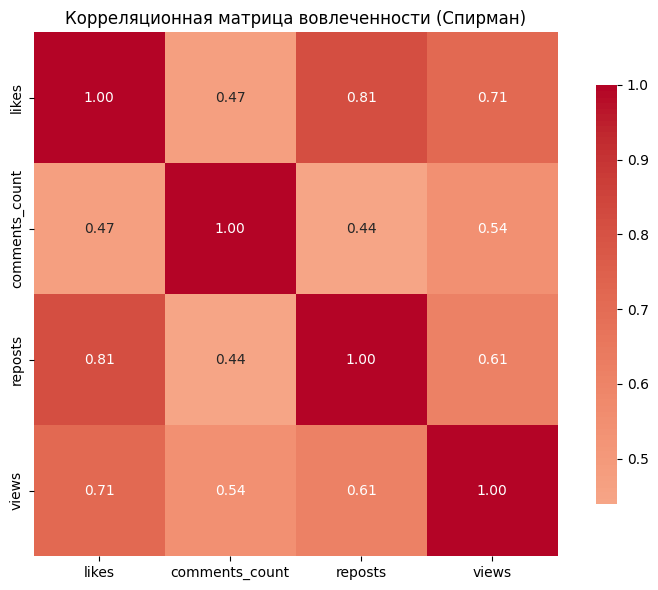

In [ ]:
edu_markers = ['вуз', 'университет', 'поступление', 'абитуриент', 'студент', 'егэ', 'бакалавриат', 'магистратура', 'вшэ', 'мгу', 'мгту', 'мфти', 'мгимо']
edu_mask = data['text'].str.lower().str.contains('|'.join(edu_markers), na=False, regex=True)
edu_sorce = (data[edu_mask].groupby('source_nickname').size()/data.groupby('source_nickname').size()).fillna(0)
edu_sorce = edu_sorce.sort_values(ascending=False).head(15).reset_index()
edu_sorce.columns= ['source_nickname', 'edu_share']
fig3 = px.bar(edu_sorce, x='source_nickname', y='edu_share',
              title='Доля постов об образовании по источникам',
              labels={'edu_share':'Доля образовательных постов', 'source_nickname':'источник'})
fig3.show()

engage = ['likes', 'comments_count', 'reposts', 'views']
corr =data[engage].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f', cbar_kws={'shrink': .8})
plt.title('Корреляционная матрица вовлеченности (Спирман)')
plt.tight_layout()
plt.show()

In [ ]:
engage_sample = data.sample(n=min(10000, len(data)), random_state=42)
fig4 = px.scatter(engage_sample, x='views', y='likes', color='year', opacity=0.5,
                  title='Зависимость лайков от просмотров (подвыборка 10 тыс.)',
                  labels={'views':'Просмотры', 'likes':'Лайки'},
                  log_x=True, log_y=True)
fig4.show()

data['text_len'] = data['text'].astype(str).progress_apply(len)
data['word_count'] = data['text'].astype(str).progress_apply(lambda x: len(x.split()))

fig5 = px.histogram(data, x='word_count', nbins=400,
                    title='Распределение количества слов в тексте',
                    labels={'count':'Частота', 'word_count':'Слов'},
                    log_y=True)
fig5.update_xaxes(range=[0,2500])
fig5.show()

100%|██████████| 779621/779621 [00:10<00:00, 71610.26it/s]


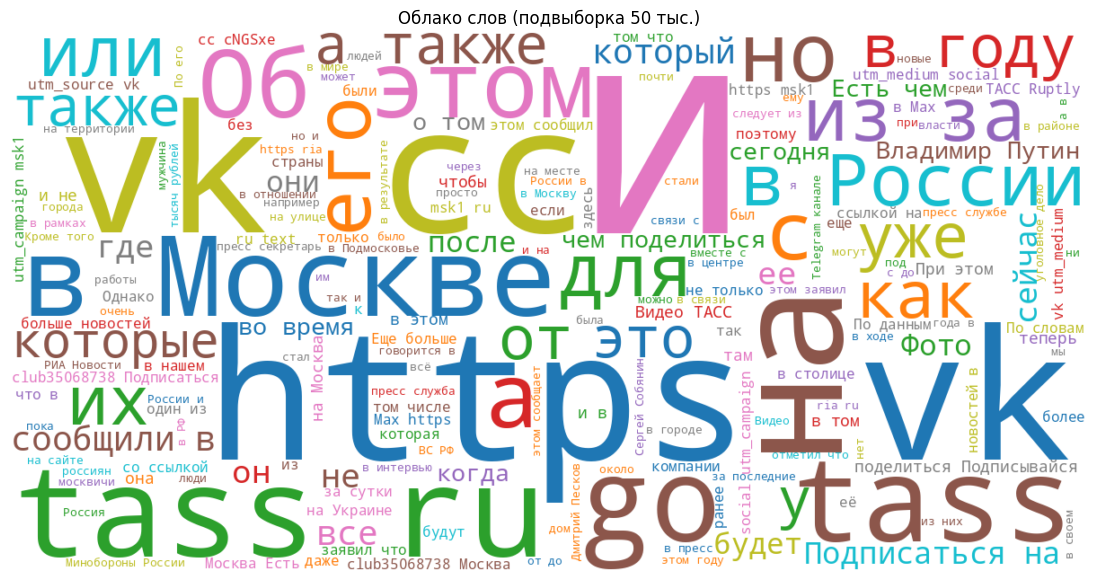

In [ ]:
cloud_sample = ' '.join(data['text'].astype(str).sample(50000, random_state=42).tolist())
wc = WordCloud(width=1200, height=600, background_color='white', max_words=200, colormap='tab10').generate(cloud_sample)
plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов (подвыборка 50 тыс.)')
plt.show()

In [ ]:
stop = set(stopwords.words('russian'))
extra_stops = {'это', 'такой', 'который', 'весь', 'быть', 'мочь', 'год', 'ещё', 'также', 'свой', 'они',
               'вот', 'мы', 'https', 'http', 'ru', 'www', 'com', 'vk' ,'cc', 'tg', 'amp', 'lt', 'club', 'ruptly' ,'max' ,'telegram' ,'всу'}
all_stops = stop.union(extra_stops)

def simple_cleanup(text):
  text = re.sub(r'http\S+', '', str(text))
  text = re.sub(r'[^\w\s]', '', text)
  text = re.sub(r'\d+', '', text)
  return text.lower()

sub_ngram = data['text'].astype(str).sample(20000, random_state=42).progress_apply(simple_cleanup)
tokens = [w for text in sub_ngram for w in text.split() if w not in all_stops and len(w)>2]

word_freq = Counter(tokens)
top_words = word_freq.most_common(30)
words, a = zip(*top_words)
print('Топ-20 слов: ', words)

bigrams = list(ngrams(tokens,2))
trigrams = list(ngrams(tokens,3))
bi_freq = Counter(bigrams).most_common(20)
tri_freq = Counter(trigrams).most_common(20)
print('Топ-20 биграмм: ', [w for  w,_ in bi_freq])
print('Топ-20 триграмм: ', [w for w,_ in tri_freq])

100%|██████████| 20000/20000 [00:00<00:00, 49563.85it/s]


Топ-20 слов:  ('россии', 'москве', 'москва', 'года', 'заявил', 'видео', 'москвы', 'сообщил', 'время', 'году', 'лет', 'изза', 'рублей', 'сша', 'которые', 'человек', 'фото', 'область', 'сегодня', 'сообщили', 'области', 'день', 'будут', 'тасс', 'путин', 'владимир', 'могут', 'президент', 'украины', 'дома')
Топ-20 биграмм:  [('владимир', 'путин'), ('поделиться', 'подписывайся'), ('подписаться', 'москва'), ('москва', 'поделиться'), ('видео', 'тассruptly'), ('риа', 'новости'), ('сергей', 'собянин'), ('тысяч', 'рублей'), ('дмитрий', 'песков'), ('минобороны', 'россии'), ('видео', 'минобороны'), ('млн', 'рублей'), ('уголовное', 'дело'), ('область', 'республика'), ('пресссекретарь', 'президента'), ('москва', 'нам'), ('нам', 'поделиться'), ('сообщили', 'прессслужбе'), ('коронавирус', 'coronavirus'), ('россии', 'владимир')]
Топ-20 триграмм:  [('москва', 'поделиться', 'подписывайся'), ('москва', 'нам', 'поделиться'), ('нам', 'поделиться', 'подписывайся'), ('россии', 'владимир', 'путин'), ('президент

In [ ]:
edu_keywords = ['вуз', 'университет', 'студент', 'поступление', 'егэ', 'бакалавриат', 'магистратура',
                'абитуриент', 'вшэ', 'мгу', 'мфти', 'мгту', 'мгимо', 'факультет', 'кафедра',
                'диплом', 'бюджет', 'коммерция', 'общежитие', 'проходной', 'балл', 'олимпиада', 'образование']
mask_theme = data['text'].str.lower().str.contains('|'.join(edu_keywords), na=False, regex=True)
edu_sample = data[mask_theme].sample(min(20000, mask_theme.sum()), random_state=42).copy()

def clenup_tfidf(text):
  text = re.sub(r'http\S+', '', str(text))
  text = re.sub(r'[^\w\s]', ' ', text)
  text = re.sub(r'\d+', '', text)
  text = ' '.join([w for w in text.lower().split() if w not in all_stops and len(w)>2])
  return text

edu_corpus =edu_sample['text'].progress_apply(clenup_tfidf).tolist()

vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7, ngram_range=(1,2))
tfidf = vectorizer.fit_transform(edu_corpus)

sset_index = np.random.choice(len(edu_corpus), size=10000, replace=False)
sset_corpus = [edu_corpus[i] for i in sset_index]
sset_tfidf = vectorizer.transform(sset_corpus)
svd100 = TruncatedSVD(n_components=100, random_state=42)
ss_tfidf = svd100.fit_transform(sset_tfidf)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean')
labels = clusterer.fit_predict(sset_tfidf)

sset_2 = TruncatedSVD(n_components=2, random_state=42).fit_transform(ss_tfidf)
fig6 = px.scatter(x=sset_2[:,0], y=sset_2[:,1], color=labels.astype(str),
                  title='',
                  labels={'x':'LSA1', 'y':'LSA2','color':'Кластер'})
fig6.show()

feature_names = np.array(vectorizer.get_feature_names_out())
print('\n Топ-слова по кластерам:')
for a in sorted(set(labels)):
  if a ==-1:
    continue
  index = np.where(labels==a)[0]
  mean_tfidf = sset_tfidf[index].mean(axis=0).A1
  top_index = mean_tfidf.argsort()[-12:][::-1]
  print(f' Кластер {a}: {feature_names[top_index].tolist()}')

100%|██████████| 20000/20000 [00:01<00:00, 14728.45it/s]



 Топ-слова по кластерам:
 Кластер 0: ['пробки', 'пробки баллов', 'баллов', 'москве', 'трлн рублей', 'трлн', 'рублей', 'образования', 'высшего образования', 'высшего', 'фальков', 'науки высшего']
 Кластер 1: ['мгу', 'саду мгу', 'ботаническом', 'ботаническом саду', 'саду', 'фото', 'аптекарский', 'аптекарский огород', 'огород', 'сад мгу', 'мгу аптекарский', 'ботанический сад']
 Кластер 2: ['vdmsti', 'джонса хопкинса', 'джонса', 'хопкинса', 'университета джонса', 'коронавирусом', 'превысило', 'кндр', 'число', 'мире', 'интересные материалы', 'главные самые']


In [ ]:
path = '/content/drive/MyDrive/мага/Диссер/data_nonan.csv'
data = pd.read_csv(path, parse_dates=['date'])

MOSCOW_UNIS_EXACT = ["МГУ", "МГУ им. Ломоносова",
    "ВШЭ", "НИУ ВШЭ", 'Вышка',
    "МФТИ", "Физтех",
    "МГТУ", "МГТУ им. Баумана", "Бауманка",
    "МГИМО",
    "МИФИ", "НИЯУ МИФИ",
    "МИСиС",
    "МИРЭА", "МИРЭА-РТУ",
    "РАНХиГС", "Плехановка",
    "РЭУ", "РГГУ",
    "МЭИ",
    "РУДН",
    "МПГУ", "МГСУ", "МАИ", "МАДИ", "МАРХИ",
    "МГУПИ", "МТУСИ", "МГТУ ГА", "МГУПП", "МГУТУ",
    "МГОУ", "Шолохова",
    "МГИК", "Герасимова",
    "МГАВМиБ", "Скрябина",
    "ГИТИС", "Щепкинское", "Щепка", "Щукина", "МХАТ",
    "ГЦОЛИФК", "МВА", "МИД", "МЧС", "МВД", "ФСБ", "РВСН",
    "ВАВТ", "ВАГШ", "РГУ", "МИРБИС", "Сколтех", "Станкин"]

MOSCOW_UNIS_PHRASE = ["Академия внешней разведки",
    "Академия водного транспорта",
    "Академия Государственной противопожарной службы МЧС России",
    "Академия гражданской защиты МЧС России",
    "Академия труда и социальных отношений",
    "Академия управления МВД России",
    "Академия Федеральной службы безопасности имени Ф. Э. Дзержинского",
    "Академия хорового искусства имени В. С. Попова",
    "Британская высшая школа дизайна",
    "Военная академия Генерального штаба Вооружённых сил Российской Федерации",
    "Военная академия РВСН имени Петра Великого",
    "Военно-дипломатическая академия",
    "Военный университет Министерства обороны Российской Федерации",
    "Всероссийская академия внешней торговли",
    "Всероссийский государственный университет кинематографии имени С. А. Герасимова",
    "Всероссийский государственный университет юстиции",
    "Всероссийский заочный финансово-экономический институт",
    "Высшая школа экономики",
    "Высшее театральное училище имени М. С. Щепкина",
    "Высшие женские курсы В. А. Полторацкой",
    "Государственная академия славянской культуры",
    "Государственный академический университет гуманитарных наук",
    "Государственный институт русского языка имени А. С. Пушкина",
    "Государственный музыкально-педагогический институт имени М. М. Ипполитова-Иванова",
    "Государственный университет по землеустройству",
    "Государственный университет просвещения",
    "Государственный университет управления",
    "Дипломатическая академия МИД России",
    "Институт искусства реставрации",
    "Институт менеджмента и индустрии моды МГУТУ",
    "Институт тонких химических технологий имени М. В. Ломоносова",
    "Институт усовершенствования врачей МО РФ",
    "Литературный институт имени А. М. Горького",
    "Международный независимый эколого-политологический университет",
    "Московская академия хореографии",
    "Московская высшая школа социальных и экономических наук",
    "Московская государственная академия ветеринарной медицины и биотехнологии",
    "Московская государственная консерватория имени П. И. Чайковского",
    "Московская сельскохозяйственная академия имени К. А. Тимирязева",
    "Московский авиационный институт",
    "Московский автомобильно-дорожный государственный технический университет",
    "Московский архитектурный институт",
    "Московский городской педагогический университет",
    "Московский государственный агроинженерный университет имени В. П. Горячкина",
    "Московский государственный горный университет",
    "Московский государственный гуманитарный университет имени М. А. Шолохова",
    "Московский государственный индустриальный университет",
    "Московский государственный институт музыки имени А. Г. Шнитке",
    "Московский государственный лингвистический университет",
    "Московский государственный открытый университет имени В. С. Черномырдина",
    "Московский государственный психолого-педагогический университет",
    "Московский государственный строительный университет",
    "Московский государственный текстильный университет имени А. Н. Косыгина",
    "Московский государственный технический университет гражданской авиации",
    "Московский государственный технический университет имени Н. Э. Баумана",
    "Московский государственный университет",
    "Московский государственный университет геодезии и картографии",
    "Московский государственный университет инженерной экологии",
    "Московский государственный университет печати",
    "Московский государственный университет природообустройства",
    "Московский государственный университет спорта и туризма",
    "Московский государственный университет технологий и управления",
    "Московский государственный университет экономики, статистики и информатики",
    "Московский государственный юридический университет",
    "Московский гуманитарный университет",
    "Московский зоотехнический институт",
    "Московский индустриально-педагогический институт имени Карла Либкнехта",
    "Московский институт востоковедения",
    "Московский институт государственного и корпоративного управления",
    "Московский институт электроники и математики",
    "Московский институт электронной техники",
    "Московский институт энергобезопасности и энергосбережения",
    "Московский историко-архивный институт",
    "Московский киновидеоинститут",
    "Московский международный университет",
    "Московский педагогический государственный университет",
    "Московский пограничный институт ФСБ России",
    "Московский политехнический университет",
    "Московский технический университет связи и информатики",
    "Московский технологический институт",
    "Московский технологический университет МГУПИ",
    "Московский университет МВД России",
    "Московский физико-технический институт",
    "Московский художественный институт имени В. И. Сурикова",
    "Московский энергетический институт",
    "Национальный исследовательский ядерный университет МИФИ",
    "Независимый Московский университет",
    "Общецерковная аспирантура и докторантура имени святых равноапостольных Кирилла и Мефодия",
    "Сеченовский университет", "Первый МГМУ",
    "Православный Свято-Тихоновский гуманитарный университет",
    "Российский государственный университет нефти и газа",
    "Российская академия живописи, ваяния и зодчества",
    "Российская академия музыки имени Гнесиных",
    "Российская академия народного хозяйства и государственной службы",
    "Российская академия путей сообщения",
    "Российская государственная специализированная академия искусств",
    "Российская открытая академия транспорта",
    "Российская таможенная академия",
    "Российская экономическая школа",
    "Российский биотехнологический университет",
    "Российский государственный геологоразведочный университет имени Серго Орджоникидзе",
    "Российский государственный гуманитарный университет",
    "Российский государственный социальный университет",
    "Российский государственный технологический университет имени К. Э. Циолковского",
    "Российский государственный торгово-экономический университет",
    "Российский государственный университет имени А. Н. Косыгина",
    "Российский государственный университет правосудия",
    "Российский государственный университет туризма и сервиса",
    "Российский институт театрального искусства ГИТИС",
    "Российский национальный исследовательский медицинский университет имени Н. И. Пирогова",
    "Российский новый университет",
    "Российский православный университет",
    "Российский университет дружбы народов",
    "Российский университет медицины",
    "Российский университет спорта ГЦОЛИФК",
    "Российский университет транспорта",
    "Российский химико-технологический университет имени Д. И. Менделеева",
    "Российский экономический университет имени Г. В. Плеханова",
    "Свято-Филаретовский институт",
    "Сколковский институт науки и технологий",
    "Старообрядческий богословский институт",
    "Стрелка",
    "Театральный институт имени Бориса Щукина",
    "Университет Правительства Москвы",
    "Университет прокуратуры Российской Федерации",
    "Финансовый университет при Правительстве Российской Федерации",
    "Французский университетский колледж Москва",
    "Школа-студия МХАТ"]

EDU_MARKERS = ['вуз', 'высшее образование', 'поступление', 'абитуриент', 'студент', 'студентка',
               'бакалавриат', 'магистратура', 'аспирантура', 'специалитет', 'ординатура', 'егэ',
               'единый государственный экзамен', 'проходной балл', 'проходные баллы', 'бюджет',
               'бюджетное место', 'коммерция', 'платное обучение', 'общежитие', 'факультет',
               'кафедра', 'диплом', 'аттестат', 'олимпиада', 'олимпиадник', 'учеба', 'учебный год',
               'сессия', 'зачет', 'экзамен', 'стипендия', 'деканат', 'ректор', 'мехмат', 'приемная кампания',
               'приёмная кампания', 'целевое направление', 'целевое обучение', 'проходной', 'балл',
               'вступительные испытания', 'основные места', 'образовательный кредит']

In [ ]:
exact_part = '|'.join([r'\b' + re.escape(w) + r'\b' for w in MOSCOW_UNIS_EXACT])
edu_marker_part = '|'.join([r'\b' + re.escape(w) + r'\b' for w in EDU_MARKERS])
phrase_part = '|'.join([re.escape(w) for w in MOSCOW_UNIS_EXACT])

combined_pattern = re.compile(f'{exact_part}|{edu_marker_part}|{phrase_part}', flags=re.IGNORECASE)

uni_only = re.compile(f'({exact_part}|{'|'.join([re.escape(w) for w in MOSCOW_UNIS_EXACT])})', flags=re.IGNORECASE)

In [ ]:
!pip install pymorphy3

In [ ]:
print('Запускаем фильтрацию')
edu_mask = data['text'].astype(str).progress_apply(lambda x: bool(combined_pattern.search(x)))
df_edu = data[edu_mask].copy()

excl_sch = re.compile(r'\b(детский сад|начальная школа|дошкольное|школьник младших классов|'
                      r'начальное образование|кружок для дошкольников|подготовительные курсы)\b',
                      flags=re.IGNORECASE)

excl_mask = df_edu['text'].astype(str).progress_apply(lambda x: bool(excl_sch.search(x)))
df_edu = df_edu[~excl_mask].copy()

df_edu['matched_uni'] = df_edu['text'].astype(str).str.extract(uni_only, expand=False)

morph = pymorphy3.MorphAnalyzer()
nltk_stopwords = set(stopwords.words('russian'))
extra_stops = {'https', 'http', 'www', 'ru', 'com', 'vk', 'cc', 'tg', 'youtube', 'amp','gt',
               'lt', 'nbsp', 'mdash', 'ndash', 'raquo', 'laquo', 'hellip', 'quot', 'club', 'всу', 'ruptly', 'max', 'telegram'}
all_stops = nltk_stopwords.union(extra_stops)

def cleanup_lemms(text):
  text = re.sub(r'http\S+|www.\S+|@\w+|<.*?>', ' ', str(text))
  text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text, flags=re.UNICODE)
  text = re.sub(r'[^\w\s]', '', text)
  text = re.sub(r'\d+', '', text)
  words= text.lower().split()
  lemmas = []
  for w in words:
    if w in all_stops or len(w)<=2:
      continue
      lemma = morph.parse(w)[0].normal_form
      if lemma not in all_stops and len(lemma)>2:
        lemmas.append(lemma)
  return ' '.join(lemmas)

print('Лемматизация')
df_edu['text_clean'] = df_edu['text'].progress_apply(cleanup_lemms)
df_edu= df_edu[df_edu['text_clean'].str.len() >0].copy()

df_edu['text_len'] = df_edu['text'].astype(str).apply(len)
df_edu['n_sentences'] = df_edu['text'].astype(str).apply(lambda x: len(re.split(r'[.?!]+', x)))
df_edu['n_words_raw'] = df_edu['text'].astype(str).apply(lambda x: len(x.split()))
df_edu['n_words_clean'] = df_edu['text_clean'].apply(lambda x: len(x.split()))

Запускаем фильтрацию


100%|██████████| 67842/67842 [00:01<00:00, 35479.17it/s]


Лемматизация


100%|██████████| 67796/67796 [00:05<00:00, 13246.84it/s]


In [16]:

POS = {'хороший', 'отличный', 'прекрасный', 'замечательный', 'лучший', 'победа', 'радость',
       'успех', 'гордость', 'престиж', 'престижный', 'доступный', 'возможность', 'шанс',
       'лидер', 'топ', 'сильный', 'высокий', 'качество', 'современный', 'инновационный',
       'развитие', 'поддержка', 'помощь', 'стипендия', 'бесплатно', 'бюджет', 'выгода',
       'превосходный', 'мощный', 'конкурентный', 'признанный', 'элитный', 'востребованный'}
NEG = {'плохой', 'ужасный', 'проблема', 'кризис', 'коррупция', 'скандал', 'недоступно',
       'дорого', 'деньги', 'взятка', 'провал', 'трудность', 'сложно', 'невозможно',
       'жалоба', 'негатив', 'препятствие', 'нарушение', 'обман', 'дискриминация',
       'нечестно', 'отчисление', 'задолженность', 'долг', 'недостаток', 'провал',
       'купить диплом', 'платное', 'не поступил', 'не смог', 'отказ', 'закрыть'}

def lex_sentiment(text):
  lemmas = set(text.split())
  pos = len(lemmas&POS)
  neg = len(lemmas&NEG)
  if pos > neg:
    return 'positive'
  elif neg> pos:
    return 'negative'
  return 'neutral'

print('Тональности')
df_edu['sentiment'] = df_edu['text_clean'].progress_apply(lex_sentiment)

print('Исходных текстов: ', len(data))
print('Отобрано текстов: ', len(df_edu))
print('Распределение по годам: ', df_edu['year'].value_counts().sort_index())
print('Тональность: ', df_edu['sentiment'].value_counts())

out_path = '/content/drive/MyDrive/мага/Диссер/data_edu_clean_2.csv'
df_edu.to_csv(out_path, index=False)

Тональности
Исходных текстов:  779621
Отобрано текстов:  36825
Распределение по годам:  year
2020    3026
2021    4351
2022    5979
2023    8043
2024    8068
2025    7358
Name: count, dtype: int64
Тональность:  sentiment
neutral     27614
positive     7112
negative     2099
Name: count, dtype: int64
